<a href="https://colab.research.google.com/github/ahmadzulfiqar001/python-100-days-beginner-to-advance-/blob/main/heart_disease_svm_dt_bagging_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Heart Disease Classification: SVM, Decision Tree, and Bagging

This notebook completes the full assignment:

1. Load heart disease dataset in pandas DataFrame  
2. Remove outliers using Z-score where Z > 3 or Z < -3  
3. Convert text columns into numbers using Label Encoding and One-Hot Encoding  
4. Apply feature scaling  
5. Build SVM standalone and Bagging SVM models  
6. Build Decision Tree standalone and Bagging Decision Tree models  
7. Compare model performance and explain where bagging works best  
8. Add data visualization using heatmap, box plots, count plots, pair plots, histograms, and model comparison charts


## 1. Import Required Libraries

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import zscore
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

## 2. Load Dataset

Upload `heart(2).csv` in Colab or keep it in the same folder as this notebook.


In [2]:
DATASET_PATHS = [
    '/content/heart(2).csv',
    '/content/heart.csv',
    '/mnt/data/heart(2).csv',
    'heart(2).csv',
    'heart.csv'
]

csv_path = None
for path in DATASET_PATHS:
    if os.path.exists(path):
        csv_path = path
        break

if csv_path is None:
    try:
        from google.colab import files
        uploaded = files.upload()
        csv_path = list(uploaded.keys())[0]
    except Exception:
        raise FileNotFoundError('Dataset not found. Please upload heart(2).csv')

df = pd.read_csv(csv_path)
print('Loaded dataset:', csv_path)
print('Shape:', df.shape)
df.head()

Loaded dataset: /content/heart.csv
Shape: (918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


## 3. Basic Dataset Information

In [3]:
display(df.info())
display(df.describe(include='all'))
print('Missing values:')
display(df.isnull().sum())
print('Duplicate rows:', df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


None

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
count,918.000000,918,918,918.000000,918.000000,918.000000,918,918.000000,918,918.000000,918,918.000000
unique,NaN,2,4,NaN,NaN,NaN,3,NaN,2,NaN,3,NaN
top,NaN,M,ASY,NaN,NaN,NaN,Normal,NaN,N,NaN,Flat,NaN
freq,NaN,725,496,NaN,NaN,NaN,552,NaN,547,NaN,460,NaN
mean,53.510893,NaN,NaN,132.396514,198.799564,0.233115,NaN,136.809368,NaN,0.887364,NaN,0.553377
std,9.432617,NaN,NaN,18.514154,109.384145,0.423046,NaN,25.460334,NaN,1.066570,NaN,0.497414
min,28.000000,NaN,NaN,0.000000,0.000000,0.000000,NaN,60.000000,NaN,-2.600000,NaN,0.000000
25%,47.000000,NaN,NaN,120.000000,173.250000,0.000000,NaN,120.000000,NaN,0.000000,NaN,0.000000
50%,54.000000,NaN,NaN,130.000000,223.000000,0.000000,NaN,138.000000,NaN,0.600000,NaN,1.000000
75%,60.000000,NaN,NaN,140.000000,267.000000,0.000000,NaN,156.000000,NaN,1.500000,NaN,1.000000


Missing values:


,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


Duplicate rows: 0


## 4. Target Column Distribution

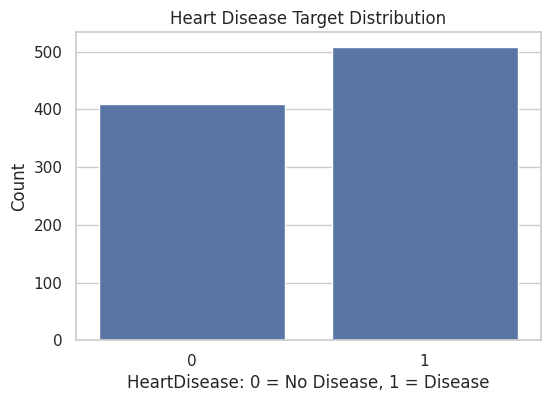

HeartDisease
1    508
0    410
Name: count, dtype: int64
Percentage:
HeartDisease
1    55.337691
0    44.662309
Name: proportion, dtype: float64


In [5]:
target_col = 'HeartDisease'

plt.figure(figsize=(6,4))
sns.countplot(data=df, x=target_col)
plt.title('Heart Disease Target Distribution')
plt.xlabel('HeartDisease: 0 = No Disease, 1 = Disease')
plt.ylabel('Count')
plt.show()

print(df[target_col].value_counts())
print('Percentage:')
print(df[target_col].value_counts(normalize=True) * 100)

## 5. Separate Numeric and Categorical Columns

In [6]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print('Numeric columns:', numeric_cols)
print('Categorical columns:', categorical_cols)

Numeric columns: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'HeartDisease']
Categorical columns: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']


## 6. Visualizations Before Preprocessing

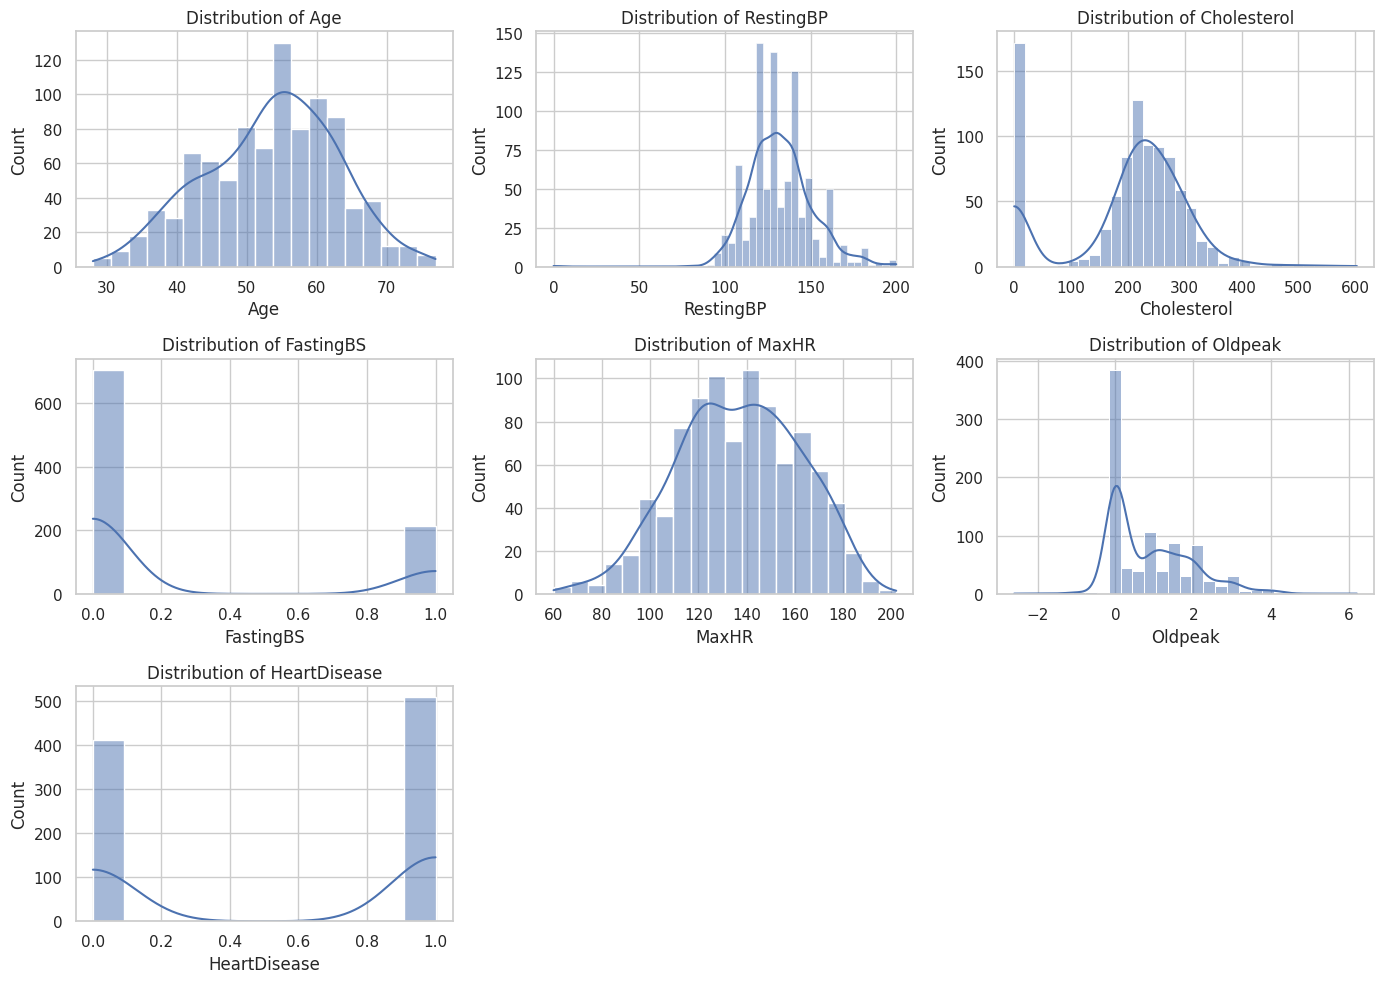

In [7]:
plt.figure(figsize=(14, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

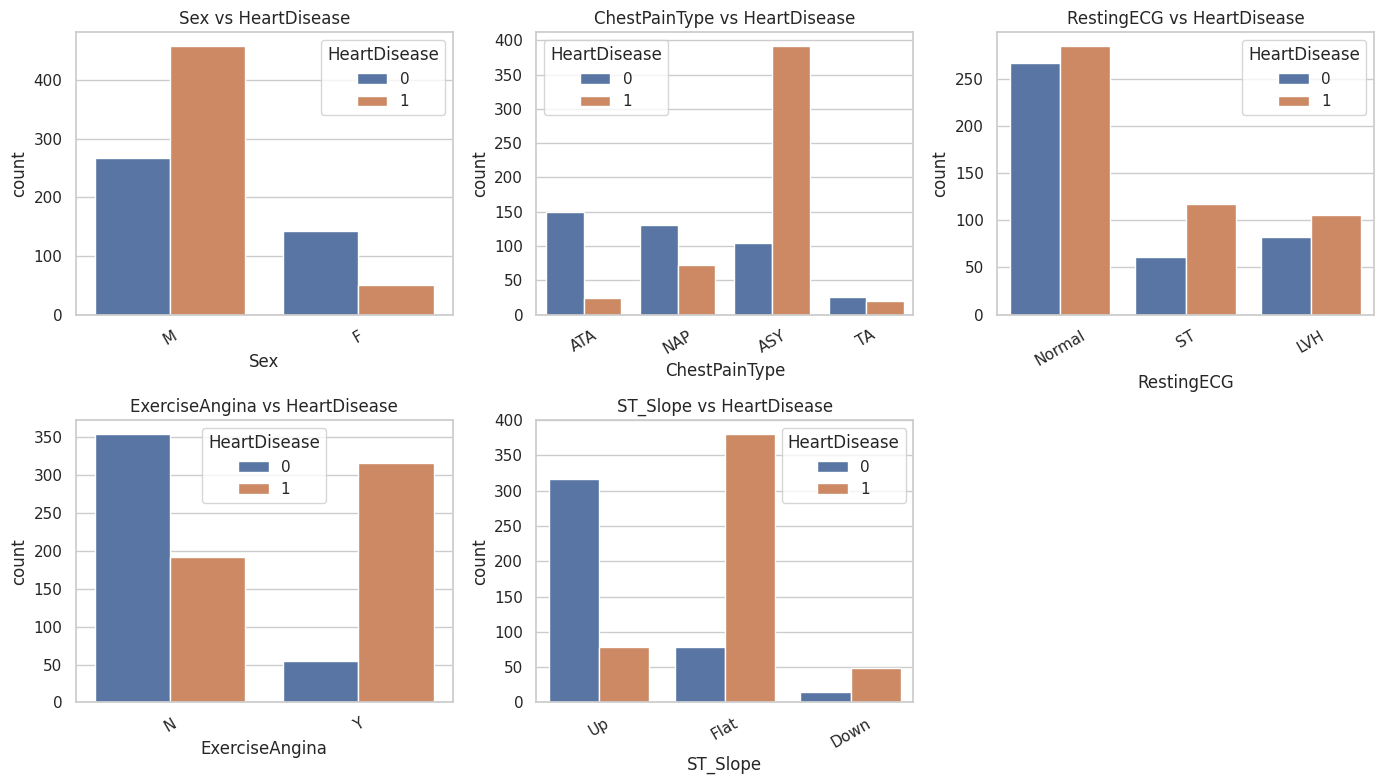

In [8]:
plt.figure(figsize=(14, 8))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(2, 3, i)
    sns.countplot(data=df, x=col, hue=target_col)
    plt.title(f'{col} vs HeartDisease')
    plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

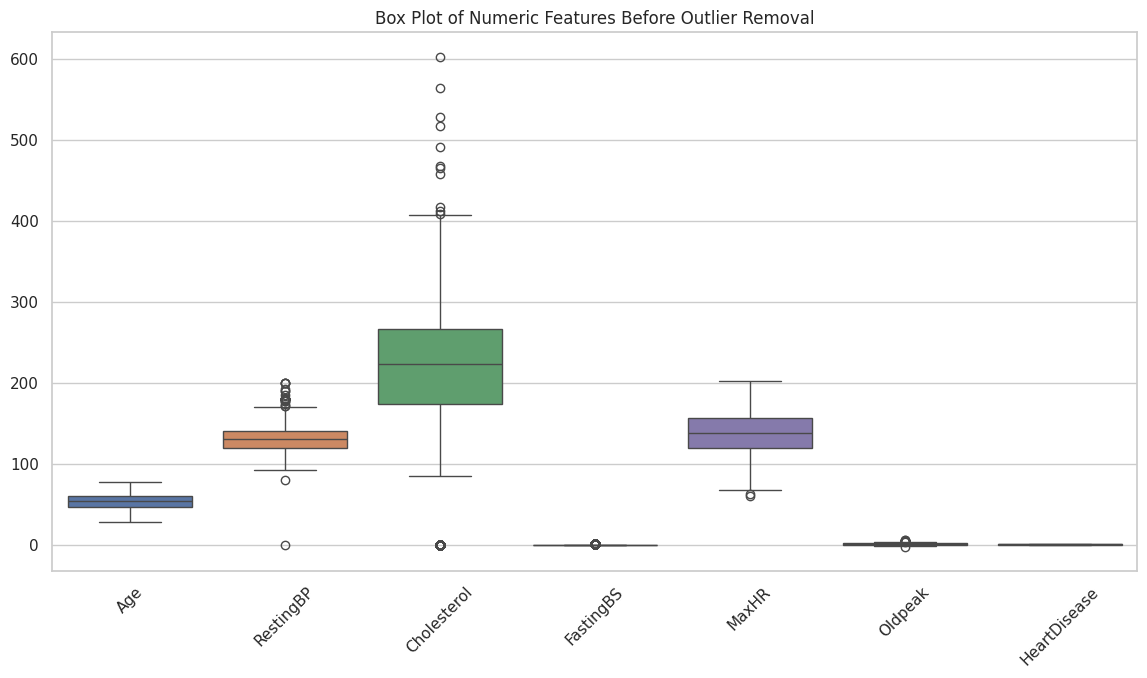

In [9]:
plt.figure(figsize=(14, 7))
sns.boxplot(data=df[numeric_cols])
plt.title('Box Plot of Numeric Features Before Outlier Removal')
plt.xticks(rotation=45)
plt.show()

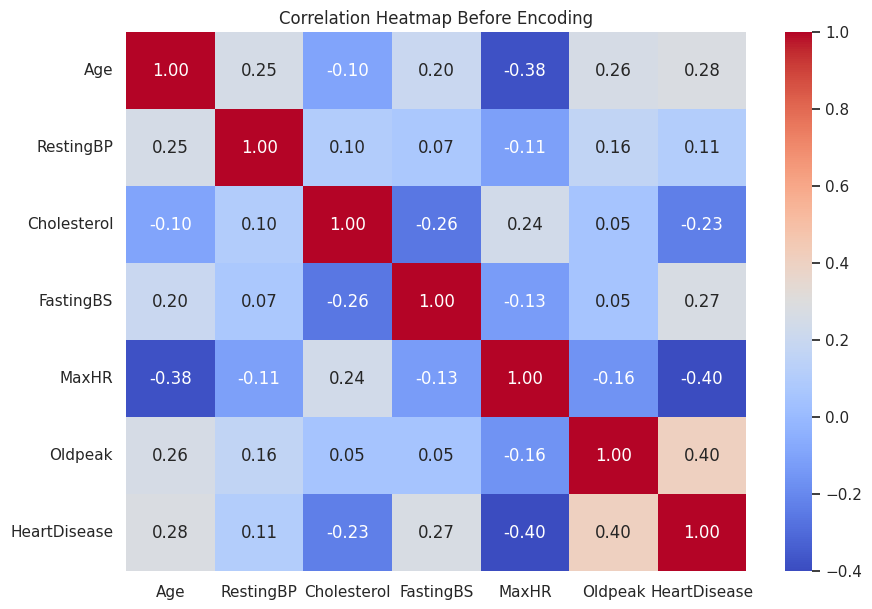

In [10]:
plt.figure(figsize=(10, 7))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap Before Encoding')
plt.show()

## 7. Remove Outliers Using Z-Score

Z-score formula:

\[
Z =
rac{x - \mu}{\sigma}
\]

Usual rule: remove rows where any numeric feature has `Z > 3` or `Z < -3`.

The target column is not used for outlier detection.


In [11]:
feature_numeric_cols = [col for col in numeric_cols if col != target_col]

z_scores = np.abs(zscore(df[feature_numeric_cols], nan_policy='omit'))
outlier_mask = (z_scores > 3).any(axis=1)

df_clean = df[~outlier_mask].copy()

print('Original shape:', df.shape)
print('Rows removed as outliers:', outlier_mask.sum())
print('Shape after outlier removal:', df_clean.shape)

Original shape: (918, 12)
Rows removed as outliers: 19
Shape after outlier removal: (899, 12)


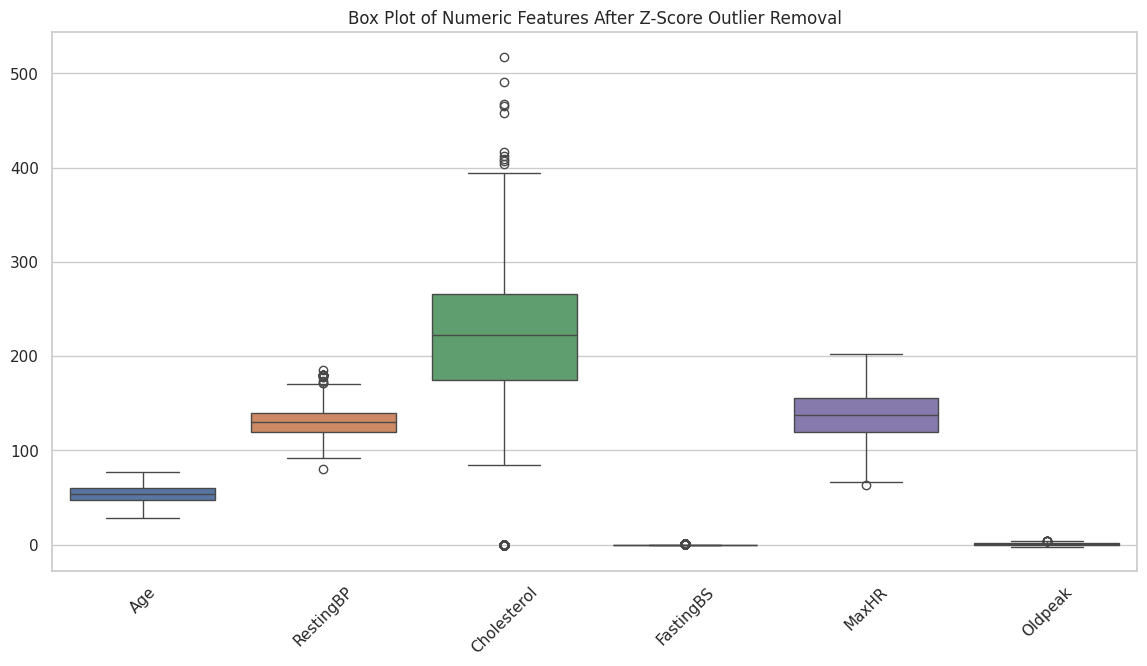

In [12]:
plt.figure(figsize=(14, 7))
sns.boxplot(data=df_clean[feature_numeric_cols])
plt.title('Box Plot of Numeric Features After Z-Score Outlier Removal')
plt.xticks(rotation=45)
plt.show()

## 8. Label Encoding Demonstration

Label Encoding converts each category into a number. It is useful for binary categorical columns like `Sex` and `ExerciseAngina`.


In [13]:
df_label_demo = df_clean.copy()
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df_label_demo[col] = le.fit_transform(df_label_demo[col])
    label_encoders[col] = le
    print(col, dict(zip(le.classes_, le.transform(le.classes_))))

df_label_demo.head()

Sex {'F': np.int64(0), 'M': np.int64(1)}
ChestPainType {'ASY': np.int64(0), 'ATA': np.int64(1), 'NAP': np.int64(2), 'TA': np.int64(3)}
RestingECG {'LVH': np.int64(0), 'Normal': np.int64(1), 'ST': np.int64(2)}
ExerciseAngina {'N': np.int64(0), 'Y': np.int64(1)}
ST_Slope {'Down': np.int64(0), 'Flat': np.int64(1), 'Up': np.int64(2)}


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,1,140,289,0,1,172,0,0.0,2,0
1,49,0,2,160,180,0,1,156,0,1.0,1,1
2,37,1,1,130,283,0,2,98,0,0.0,2,0
3,48,0,0,138,214,0,1,108,1,1.5,1,1
4,54,1,2,150,195,0,1,122,0,0.0,2,0


## 9. One-Hot Encoding for Model Training

For final model training, One-Hot Encoding is safer for multi-category text columns because it does not create false ranking between categories.


In [14]:
df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)
print('Shape after one-hot encoding:', df_encoded.shape)
df_encoded.head()

Shape after one-hot encoding: (899, 16)


,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160,180,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138,214,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150,195,0,122,0.0,0,True,False,True,False,True,False,False,False,True


## 10. Heatmap After Encoding

In [ ]:
plt.figure(figsize=(16, 12))
sns.heatmap(df_encoded.corr(), cmap='coolwarm', center=0)
plt.title('Correlation Heatmap After Encoding')
plt.show()

## 11. Pair Plot of Important Features

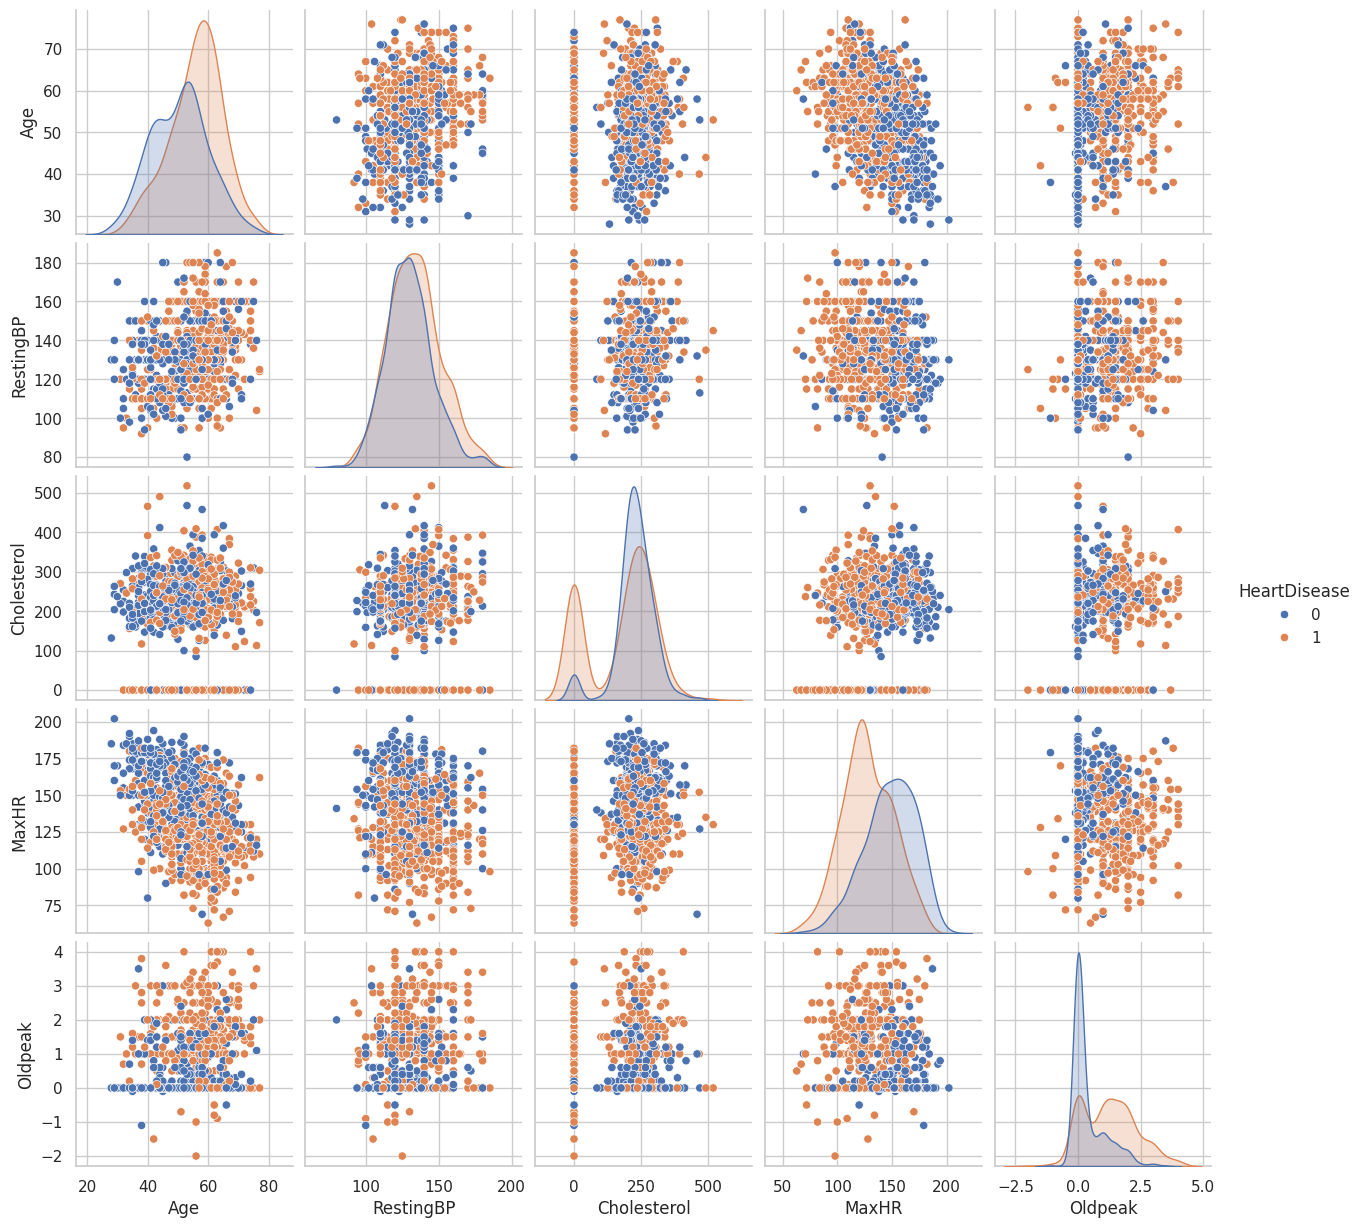

In [15]:
important_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak', target_col]
important_cols = [col for col in important_cols if col in df_clean.columns]
sns.pairplot(df_clean[important_cols], hue=target_col, diag_kind='kde')
plt.show()

## 12. Train-Test Split and Scaling

Scaling is very important for SVM because SVM uses distances between data points. Decision Tree does not need scaling, but we keep the same scaled data for fair comparison.


In [16]:
X = df_encoded.drop(target_col, axis=1)
y = df_encoded[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('X_train:', X_train.shape)
print('X_test:', X_test.shape)

X_train: (719, 15)
X_test: (180, 15)


## 13. Helper Function for Model Evaluation

In [18]:
results = []

def evaluate_model(model_name, model, X_train_data, X_test_data, y_train_data, y_test_data):
    model.fit(X_train_data, y_train_data)
    y_pred = model.predict(X_test_data)

    accuracy = accuracy_score(y_test_data, y_pred)
    precision = precision_score(y_test_data, y_pred, zero_division=0)
    recall = recall_score(y_test_data, y_pred, zero_division=0)
    f1 = f1_score(y_test_data, y_pred, zero_division=0)

    results.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1
    })

    print('=' * 70)
    print(model_name)
    print('=' * 70)
    print('Accuracy:', round(accuracy, 4))
    print('Precision:', round(precision, 4))
    print('Recall:', round(recall, 4))
    print('F1 Score:', round(f1, 4))
    print('Classification Report:')
    print(classification_report(y_test_data, y_pred))

    cm = confusion_matrix(y_test_data, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    return model, y_pred

## 14. Build SVM Standalone Model

Standalone SVM
Accuracy: 0.8944
Precision: 0.8846
Recall: 0.9293
F1 Score: 0.9064
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.85      0.88        81
           1       0.88      0.93      0.91        99

    accuracy                           0.89       180
   macro avg       0.90      0.89      0.89       180
weighted avg       0.90      0.89      0.89       180



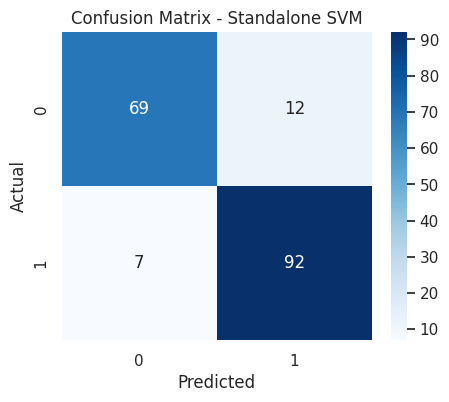

In [19]:
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=RANDOM_STATE)
svm_model, svm_pred = evaluate_model(
    'Standalone SVM', svm_model, X_train_scaled, X_test_scaled, y_train, y_test
)

## 15. Build Bagging Model Using SVM

Bagging SVM
Accuracy: 0.8889
Precision: 0.8835
Recall: 0.9192
F1 Score: 0.901
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.85      0.87        81
           1       0.88      0.92      0.90        99

    accuracy                           0.89       180
   macro avg       0.89      0.89      0.89       180
weighted avg       0.89      0.89      0.89       180



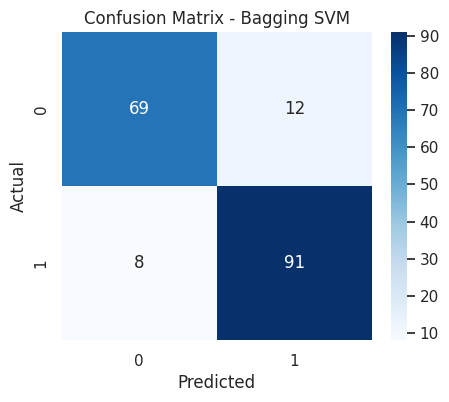

In [20]:
try:
    bagging_svm = BaggingClassifier(
        estimator=SVC(kernel='rbf', C=1.0, gamma='scale', random_state=RANDOM_STATE),
        n_estimators=30,
        max_samples=0.8,
        bootstrap=True,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
except TypeError:
    bagging_svm = BaggingClassifier(
        base_estimator=SVC(kernel='rbf', C=1.0, gamma='scale', random_state=RANDOM_STATE),
        n_estimators=30,
        max_samples=0.8,
        bootstrap=True,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

bagging_svm, bagging_svm_pred = evaluate_model(
    'Bagging SVM', bagging_svm, X_train_scaled, X_test_scaled, y_train, y_test
)

## 16. Build Decision Tree Standalone Model

Standalone Decision Tree
Accuracy: 0.85
Precision: 0.875
Recall: 0.8485
F1 Score: 0.8615
Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.85      0.84        81
           1       0.88      0.85      0.86        99

    accuracy                           0.85       180
   macro avg       0.85      0.85      0.85       180
weighted avg       0.85      0.85      0.85       180



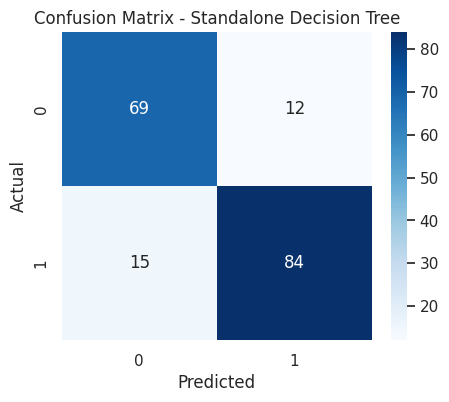

In [21]:
dt_model = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt_model, dt_pred = evaluate_model(
    'Standalone Decision Tree', dt_model, X_train_scaled, X_test_scaled, y_train, y_test
)

## 17. Build Bagging Model Using Decision Tree

Bagging Decision Tree
Accuracy: 0.8444
Precision: 0.8447
Recall: 0.8788
F1 Score: 0.8614
Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.80      0.82        81
           1       0.84      0.88      0.86        99

    accuracy                           0.84       180
   macro avg       0.84      0.84      0.84       180
weighted avg       0.84      0.84      0.84       180



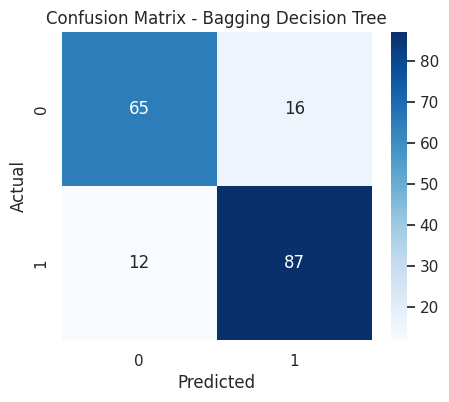

In [22]:
try:
    bagging_dt = BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
        n_estimators=100,
        max_samples=0.8,
        bootstrap=True,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
except TypeError:
    bagging_dt = BaggingClassifier(
        base_estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
        n_estimators=100,
        max_samples=0.8,
        bootstrap=True,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

bagging_dt, bagging_dt_pred = evaluate_model(
    'Bagging Decision Tree', bagging_dt, X_train_scaled, X_test_scaled, y_train, y_test
)

## 18. Decision Tree Visualization

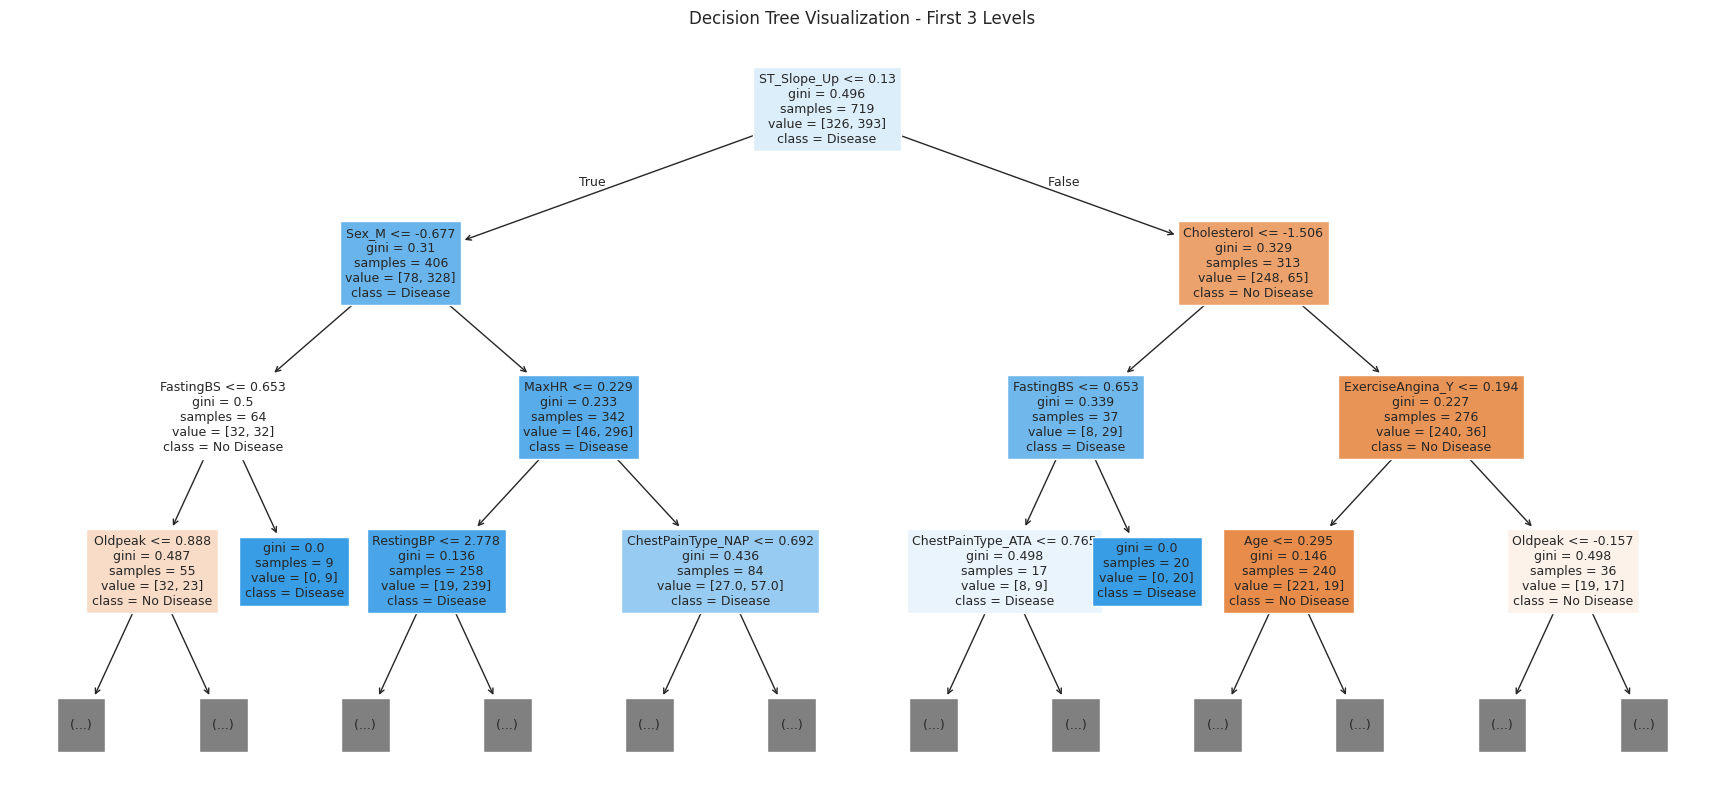

In [23]:
plt.figure(figsize=(22, 10))
plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=['No Disease', 'Disease'],
    filled=True,
    max_depth=3,
    fontsize=9
)
plt.title('Decision Tree Visualization - First 3 Levels')
plt.show()

## 19. Model Performance Comparison

In [24]:
results_df = pd.DataFrame(results)
display(results_df.sort_values(by='Accuracy', ascending=False))

,Model,Accuracy,Precision,Recall,F1 Score
0,Standalone SVM,0.894444,0.884615,0.929293,0.906404
1,Bagging SVM,0.888889,0.883495,0.919192,0.900990
2,Standalone Decision Tree,0.850000,0.875000,0.848485,0.861538
3,Bagging Decision Tree,0.844444,0.844660,0.878788,0.861386


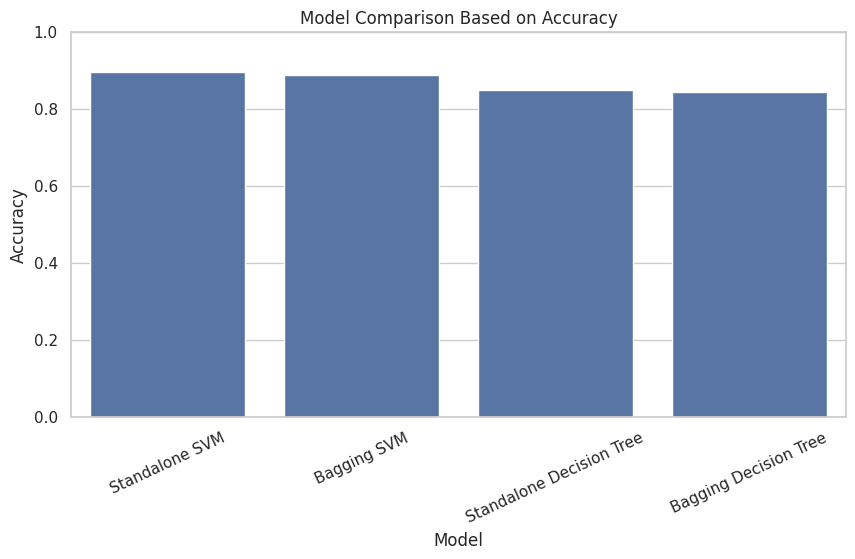

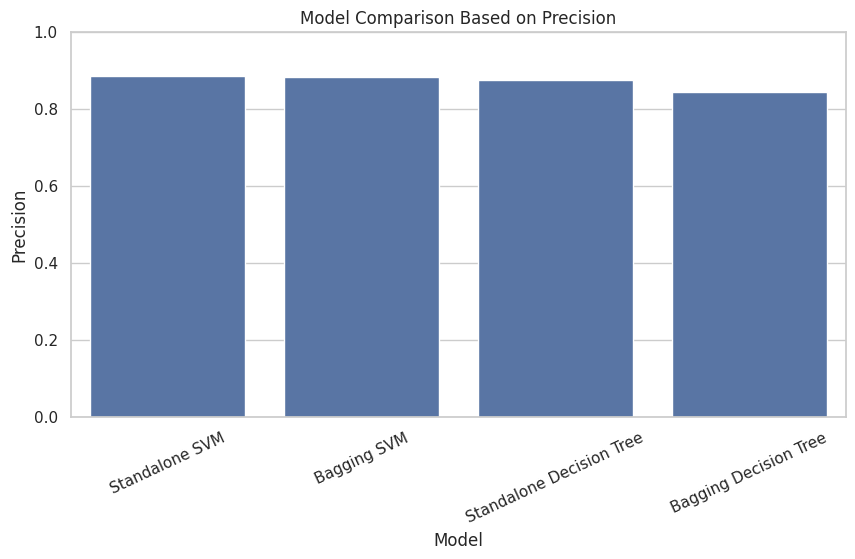

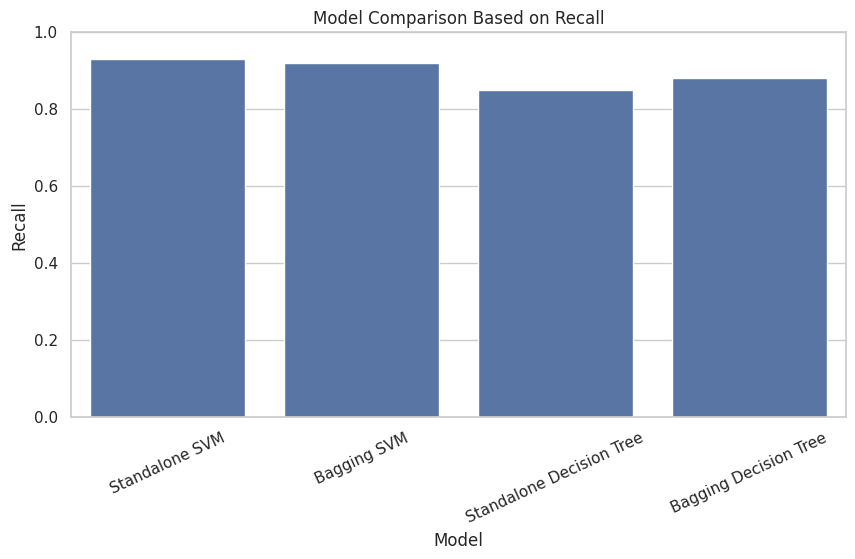

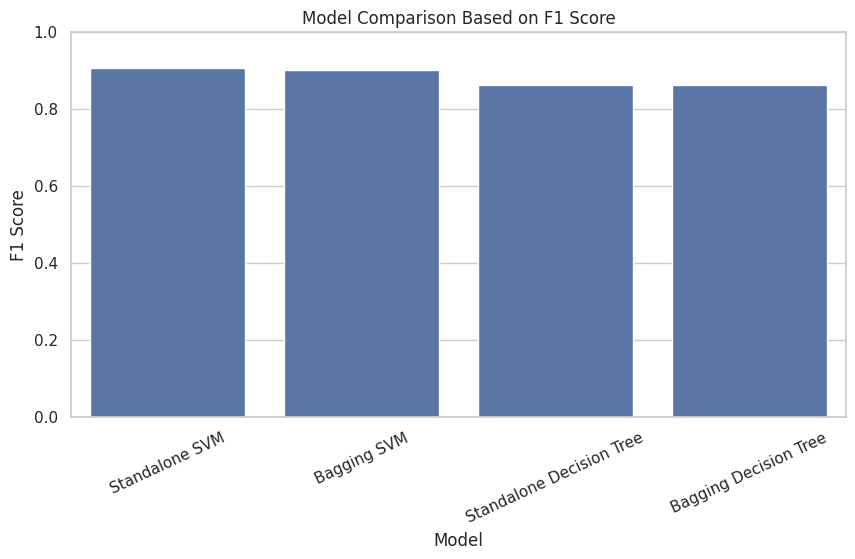

In [25]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

for metric in metrics:
    plt.figure(figsize=(10, 5))
    sns.barplot(data=results_df, x='Model', y=metric)
    plt.title(f'Model Comparison Based on {metric}')
    plt.ylim(0, 1)
    plt.xticks(rotation=25)
    plt.show()

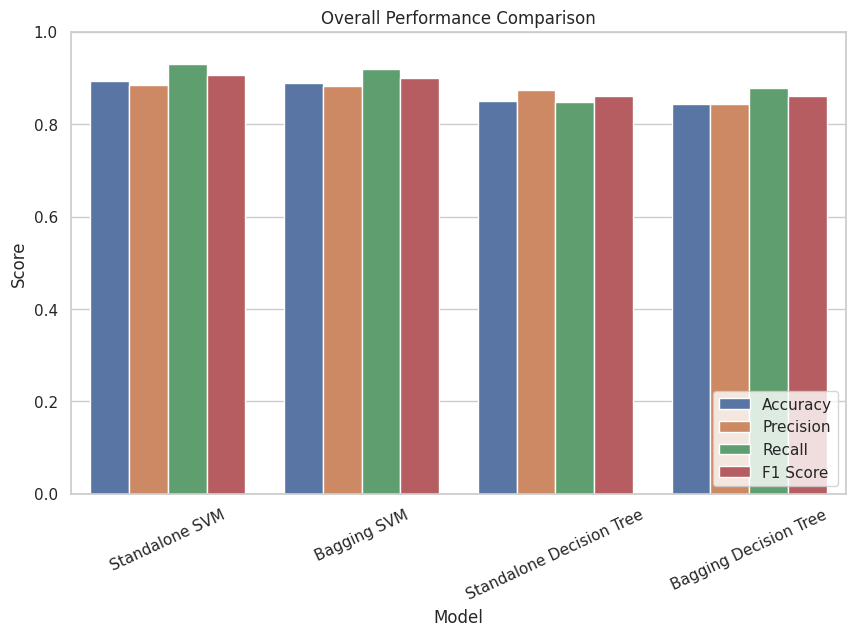

In [26]:
plt.figure(figsize=(10, 6))
results_melted = results_df.melt(id_vars='Model', value_vars=metrics, var_name='Metric', value_name='Score')
sns.barplot(data=results_melted, x='Model', y='Score', hue='Metric')
plt.title('Overall Performance Comparison')
plt.ylim(0, 1)
plt.xticks(rotation=25)
plt.legend(loc='lower right')
plt.show()

## 20. Difference Between Standalone and Bagging Models

,SVM Bagging Improvement,Decision Tree Bagging Improvement
Accuracy,-0.005556,-0.005556
Precision,-0.001120,-0.030340
Recall,-0.010101,0.030303
F1 Score,-0.005414,-0.000152


<Figure size 1000x500 with 0 Axes>

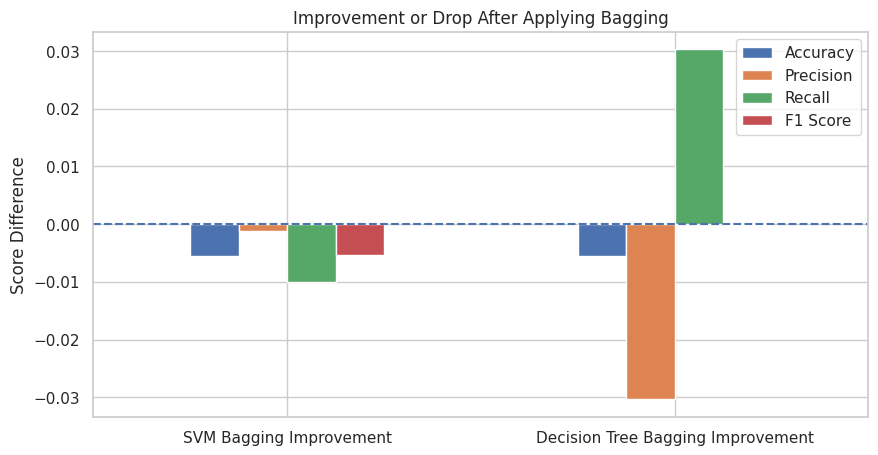

In [27]:
comparison = results_df.set_index('Model')

svm_diff = comparison.loc['Bagging SVM'] - comparison.loc['Standalone SVM']
dt_diff = comparison.loc['Bagging Decision Tree'] - comparison.loc['Standalone Decision Tree']

diff_df = pd.DataFrame({
    'SVM Bagging Improvement': svm_diff,
    'Decision Tree Bagging Improvement': dt_diff
})

display(diff_df)

plt.figure(figsize=(10, 5))
diff_df.T.plot(kind='bar', figsize=(10, 5))
plt.title('Improvement or Drop After Applying Bagging')
plt.ylabel('Score Difference')
plt.axhline(0, linestyle='--')
plt.xticks(rotation=0)
plt.show()

## 21. Final Analysis: Where Does Bagging Make More Sense?

Bagging means Bootstrap Aggregating. It trains many versions of the same model on random samples of the data and then combines their predictions. According to scikit-learn documentation, BaggingClassifier is mainly used to reduce variance in a base estimator such as a decision tree. The scikit-learn ensemble guide also explains that bagging works best with strong and complex models, especially fully grown decision trees, because these models can overfit and have high variance.

### Expected finding

Bagging usually makes more sense with **Decision Tree Classifier** than with **SVM**.

### Why?

A standalone decision tree can easily overfit because it can create many deep rules from the training data. This makes it a high-variance model. Bagging reduces this problem by training many trees on different bootstrap samples and averaging/voting their predictions.

SVM is usually more stable, especially when regularization is used. Because of this, Bagging SVM may not improve performance much and can also increase training time.

### Simple conclusion

Use bagging when:

- The model has high variance
- The model overfits the training data
- The dataset has noise
- The base model is unstable, like a deep decision tree
- You want more stable predictions

Bagging is usually less useful when:

- The model is already stable
- The model has high bias
- The dataset is very small
- Training many models becomes too slow

References used for this explanation:

- scikit-learn BaggingClassifier documentation: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.BaggingClassifier.html
- scikit-learn Ensemble methods guide: https://scikit-learn.org/stable/modules/ensemble.html
- IBM Bagging explanation: https://www.ibm.com/think/topics/bagging


## 22. Final Automatic Conclusion Based on Your Notebook Results

In [28]:
best_model = results_df.sort_values(by='Accuracy', ascending=False).iloc[0]

print('Best model based on Accuracy:')
print(best_model)

print('Conclusion:')
print('Compare the standalone and bagging scores above.')
print('If Bagging Decision Tree improves over Standalone Decision Tree, then bagging is useful here because decision trees are high-variance models.')
print('If Bagging SVM has small improvement or no improvement, it means SVM was already stable on this dataset.')

Best model based on Accuracy:
Model        Standalone SVM
Accuracy           0.894444
Precision          0.884615
Recall             0.929293
F1 Score           0.906404
Name: 0, dtype: object
Conclusion:
Compare the standalone and bagging scores above.
If Bagging Decision Tree improves over Standalone Decision Tree, then bagging is useful here because decision trees are high-variance models.
If Bagging SVM has small improvement or no improvement, it means SVM was already stable on this dataset.
